# investalyze: vector structure (k-NN + PCA)


Before clustering history vectors into motifs (notebook 5), sanity-check the representation: **does it put similar shapes near each other?** Two cheap, stateless diagnostics answer that:

1. **k-nearest-neighbours**, pull the globally closest history pairs and eyeball them.
2. **PCA embedding**, project the vectors to 2-D and look at the global structure.

If near vectors look alike and the embedding shows structure, clustering is worth doing. Builds on the `segments` + `encodings` layer demonstrated in notebook 3.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
import faiss
import matplotlib.pyplot as plt
import numpy as np
from helpers import connect_readonly

from investalyze.analysis import encodings, segments

con = connect_readonly()

## 1. Build the vectors

The shared preamble: load a universe → chop into windows → split history/future → encode the histories. A mix of stocks and indices makes the embedding more interesting. We encode with **rebase-to-100** (amplitude-aware) and compare with **Euclidean** distance, the pairing notebook 3 recommended for motif work.

In [ ]:
CLASSES = ['stocks', 'indices']
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'JPM', '^DJI', '^NDX', '^UKX', '^AEX']  # or None for every ticker

CLASSES = ['indices']
TICKERS = None

HISTORY_LENGTH = 200
FUTURE_LENGTH = 1
WINDOW_LENGTH = HISTORY_LENGTH + FUTURE_LENGTH
STRIDE = 1

series = segments.load_series(con, classes=CLASSES, tickers=TICKERS)
W, meta = segments.build_segments(series, window_length=WINDOW_LENGTH, stride=STRIDE)
history = W[:, :HISTORY_LENGTH]
future = W[:, HISTORY_LENGTH:]
X = encodings.rebase_to_100(history)  # amplitude-aware, Euclidean-friendly (see notebook 3)

print('vectors X', X.shape, 'from', len(meta), 'windows across', meta['Ticker'].nunique(), 'tickers')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

vectors X (622279, 200) from 622279 windows across 62 tickers


## 2. Find similar pairs (k-NN)

**faiss** gives each vector its nearest neighbour under Euclidean distance. We use `IndexFlatL2` (exact, brute-force but SIMD-vectorised and multithreaded), it scales to far more vectors than a KD-tree, which degrades badly above ~10-20 dimensions. Sorting by neighbour distance surfaces the globally closest history pairs; overlaying each pair is the eyeball test, *do the closest vectors trace the same shape?*

(Euclidean on rebase-to-100 rewards same shape **and** same move size. Cosine similarity would measure angle only and, on rebased vectors that all start at 100, is degenerate unless you centre first, so we stay with Euclidean here. At tens of millions of vectors, swap `IndexFlatL2` for an approximate index, `IndexIVFFlat` or `IndexHNSWFlat`.)

In [3]:
Xf = np.ascontiguousarray(X, dtype='float32')  # faiss wants contiguous float32
index = faiss.IndexFlatL2(Xf.shape[1])
index.add(Xf)
sq_dist, nn = index.search(Xf, 2)  # IndexFlatL2 returns SQUARED L2; column 0 is the point itself
nn_dist = np.sqrt(sq_dist[:, 1])
nn_idx = nn[:, 1]

# the globally closest distinct pairs (dedupe i<->j), nearest first
pairs = []
seen = set()
for i in np.argsort(nn_dist):
    j = nn_idx[i]
    key = (min(i, j), max(i, j))
    if key in seen:
        continue
    seen.add(key)
    pairs.append((int(i), int(j), nn_dist[i]))
    if len(pairs) == 6:
        break

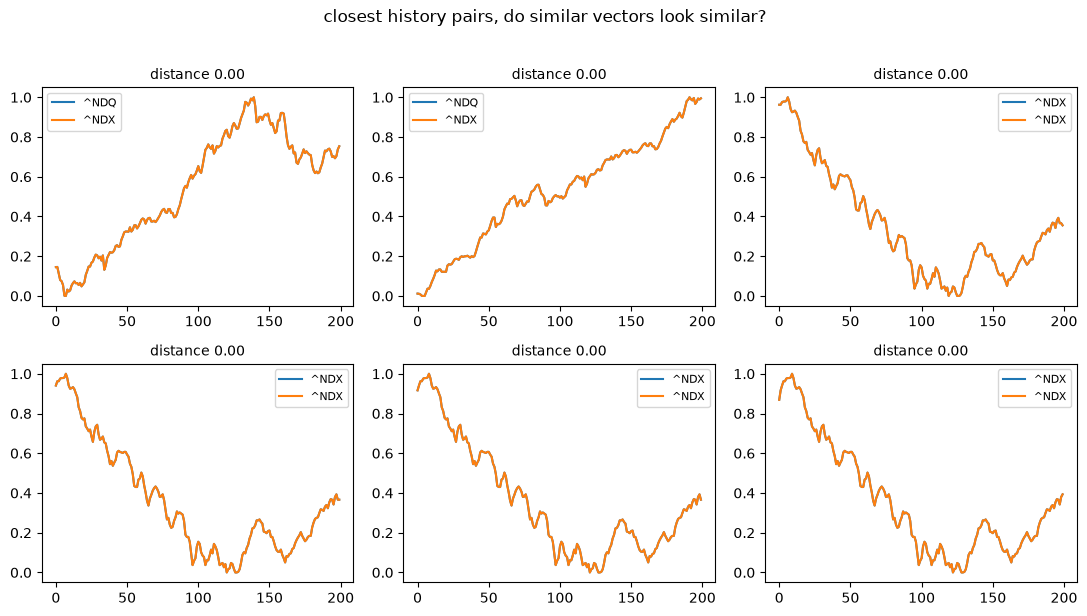

In [4]:
xs = np.arange(HISTORY_LENGTH)
fig, axes = plt.subplots(2, 3, figsize=(11, 6))
for ax, (i, j, d) in zip(axes.flat, pairs):
    ax.plot(xs, X[i], label=meta.loc[i, 'Ticker'])
    ax.plot(xs, X[j], label=meta.loc[j, 'Ticker'])
    ax.set_title(f'distance {d:.2f}', fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle('closest history pairs, do similar vectors look similar?', y=1.02)
plt.tight_layout()
plt.show()

## 3. Embed & visualise (PCA)

PCA (via SVD) projects the 20-D vectors onto their two highest-variance directions, a dependency-free linear embedding. The explained-variance share says how much shape survives the projection; the scatter, coloured by asset class, shows whether the vectors clump or spread. (For nonlinear structure, UMAP/t-SNE would be a later add, they need extra dependencies.)

In [5]:
Xc = X - X.mean(axis=0)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
coords = U[:, :2] * S[:2]
explained = S ** 2 / (S ** 2).sum()
print(f'PC1 {explained[0]:.1%}, PC2 {explained[1]:.1%} of variance')

PC1 46.0%, PC2 19.2% of variance


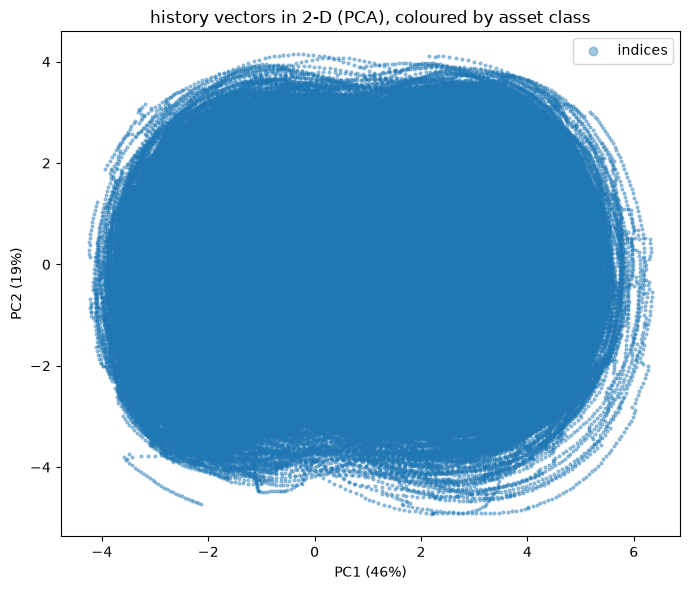

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
for cls, sub in meta.groupby('AssetClass'):
    rows = sub.index.to_numpy()
    ax.scatter(coords[rows, 0], coords[rows, 1], s=4, alpha=0.4, label=cls)
ax.set_xlabel(f'PC1 ({explained[0]:.0%})')
ax.set_ylabel(f'PC2 ({explained[1]:.0%})')
ax.legend(markerscale=3)
ax.set_title('history vectors in 2-D (PCA), coloured by asset class')
plt.tight_layout()
plt.show()